In [3]:
!python sentiment-analysis-amazon/data/download_data.py --url http://snap.stanford.edu/data/finefoods.txt.gz

2025-04-30 08:43:17 — INFO — Downloading from http://snap.stanford.edu/data/finefoods.txt.gz...
2025-04-30 08:43:21 — INFO — Downloaded to data/raw/finefoods.txt.gz
2025-04-30 08:43:21 — INFO — Extracting...
2025-04-30 08:43:24 — INFO — Extracted to data/raw/finefoods.txt


In [2]:
import pandas as pd
from data.data_loader import DataLoader

data_loader = DataLoader("data/raw/finefoods.txt")
data = data_loader.load()
data.score = data.score.astype(float)

2025-04-30 08:46:24 — INFO — Initializing dataloader...
2025-04-30 08:46:24 — INFO — Parsing dataset...
Parsing line: 5116093it [00:02, 2152093.97it/s]
2025-04-30 08:46:26 — INFO — Creating dataframe...


<Axes: title={'center': 'Label distribution'}, xlabel='score'>

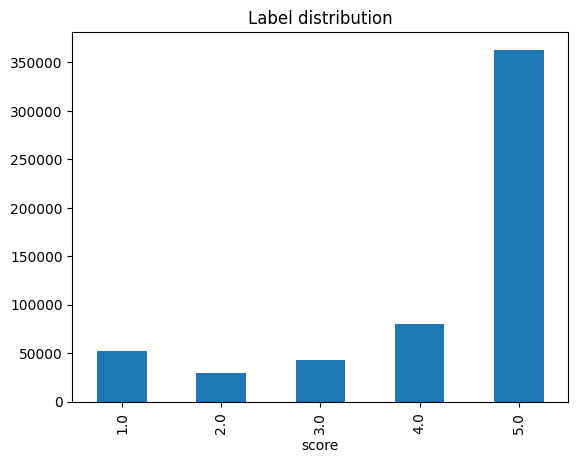

In [3]:
import matplotlib.pyplot as plt

data.score.value_counts().sort_index().plot(
    kind="bar", title="Label distribution"
)

In [71]:
augmented_data = pd.read_csv(
    "aff_summary_text_q75_augmented_merged.csv", 
    dtype=str
)
augmented_data.score = augmented_data.score.astype(float)
augmented_data.text = augmented_data.text.astype(str) # due to failed augmentation
augmented_data.summary = augmented_data.summary.astype(str) # due to failed augmentation

<Axes: title={'center': 'Label distribution'}, xlabel='score'>

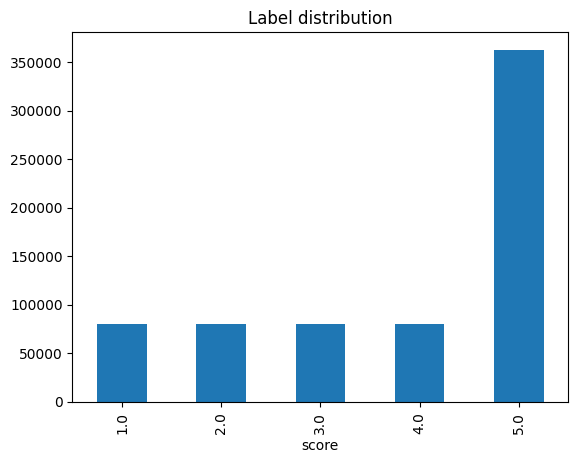

In [73]:
augmented_data.score.value_counts().sort_index().plot(
    kind="bar", title="Label distribution"
)

In [72]:
augmented_data.score.value_counts() # check of data load

score
5.0    362936
2.0     80651
3.0     80629
4.0     80627
1.0     80618
Name: count, dtype: int64

In [4]:
from sklearn.utils import resample

def downsample(data, seed=42):
  min_class_size = data['score'].value_counts().min()

  dfs = []
  for label in data['score'].unique():
      class_subset = data[data['score'] == label]
      downsampled = resample(
          class_subset,
          replace=False,            
          n_samples=min_class_size,  
          random_state=seed
      )
      dfs.append(downsampled)

  return pd.concat(dfs).sample(frac=1, random_state=42).reset_index(drop=True)

downsampled_augmented_data = downsample(data)

In [5]:
downsampled_augmented_data.score.value_counts()

score
1.0    29769
5.0    29769
4.0    29769
3.0    29769
2.0    29769
Name: count, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split

def build_train_test_val_sets(data: pd.DataFrame, test_size=0.2, val_size=0.2, seed=42, stratify=True):
  X = (data['summary'] + " " + data['text']).to_list()
  y = (data['score'].astype(int) - 1).to_list()
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=test_size, random_state=seed,
      stratify=y if stratify else None
  )
  X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=val_size, random_state=seed,
    stratify=y_train if stratify else None
  )
  return (X_train, y_train), (X_test, y_test), (X_val, y_val)

(X_train, y_train), (X_test, y_test), (X_val, y_val) = build_train_test_val_sets(downsampled_augmented_data)

In [7]:
import torch 
from transformers import (
    BertTokenizer, 
    BertForSequenceClassification, 
    Trainer, 
    TrainingArguments
)
from torch.utils.data import Dataset

class SentimentDataset(Dataset):
  def __init__(self, texts, labels, tokenizer, max_len=512):
    self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=max_len)
    self.labels = list(labels)  
  
  def __getitem__(self, idx):
    item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
    item['labels'] = torch.tensor(self.labels[idx])
    return item

  def __len__(self):
    return len(self.labels)


In [12]:
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = RobertaTokenizerFast.from_pretrained("roberta-base")
model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=5  
).to(device)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
train_dataset = SentimentDataset(X_train, y_train, tokenizer)
test_dataset = SentimentDataset(X_test, y_test, tokenizer)
val_dataset = SentimentDataset(X_val, y_val, tokenizer)

In [10]:
import numpy as np
from sklearn.metrics import f1_score, root_mean_squared_error

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    f1_macro = f1_score(labels, preds, average="macro")
    rmse = root_mean_squared_error(labels, preds)
    return {
        "f1_macro": f1_macro,
        "rmse": rmse #advised in task assignment
    }

In [13]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results/roberta",
    overwrite_output_dir=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="rmse",
    greater_is_better=False,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    fp16=True,
    learning_rate=2e-5,
    weight_decay=0.01,
    num_train_epochs=3,
    warmup_steps=500,
    logging_dir="./logs",
    logging_strategy="steps",
    logging_steps=1_000,
    report_to="none",
    seed=42
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,F1 Macro,Rmse
1,0.823700,0.749361,0.687481,0.669906
2,0.677400,0.705406,0.715860,0.638192
3,0.568600,0.714427,0.730001,0.615075


TrainOutput(global_step=8931, training_loss=0.7104599072489782, metrics={'train_runtime': 1412.0799, 'train_samples_per_second': 202.382, 'train_steps_per_second': 6.325, 'total_flos': 7.519390275336192e+16, 'train_loss': 0.7104599072489782, 'epoch': 3.0})

In [14]:
predictions = trainer.predict(test_dataset)

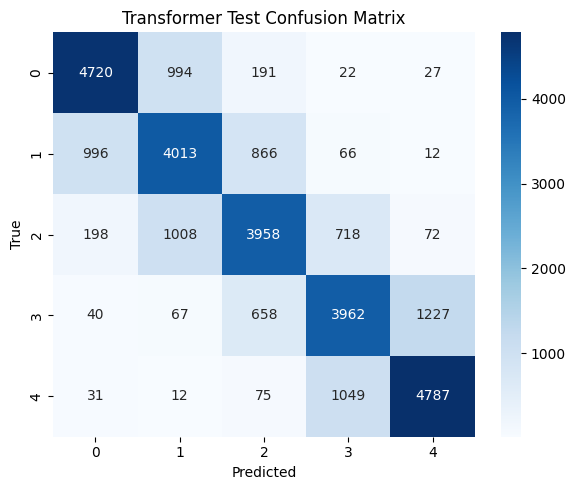

In [63]:
from utils.evaluation import evaluate_model, plot_confusion_matrix
from utils.io_utils import save_metrics, save_reports
test_metrics = {
    "acc": [],
    "RMSE": [],
    "f1_macro": [],
    "f1_micro": []
}

test_report = []
test_metrics_path = "metrics/test/roberta_3e_originaldata_undersampled.csv"
test_report_path = "reports/test/roberta_3e_originaldata_undersampled.json"
y_pred = predictions.predictions.argmax(axis=1)
evaluate_model(y_test, y_pred, metrics=test_metrics, reports=test_report)

save_metrics(test_metrics, test_metrics_path)
save_reports(test_report, test_report_path)
plot_confusion_matrix(y_test, y_pred, title="Transformer Test Confusion Matrix")

In [54]:
model.eval()
idx = random.sample(range(len(X_test)), 10)
review_examples = [X_test[i] for i in idx]
review_sentiments = [y_test[i] for i in idx]
tokenized = tokenizer(review_examples, return_tensors="pt", padding=True, truncation=True).to(device)

with torch.no_grad():
    outputs = model(**tokenized)
    preds = torch.argmax(outputs.logits, dim=1).cpu().tolist() 

for i, (review, true_label, pred_label) in enumerate(zip(review_examples, review_sentiments, preds)):
    print("REVIEW TEXT:")
    print(review)
    print(f"REAL SENTIMENT SCORE: {true_label + 1}")
    print(f"PREDICTED SENTIMENT SCORE: {pred_label + 1}")
    print("-------------------------------------------")

REVIEW TEXT:
Perfect Gluten Free Snack I grab one of these bars in the morning as I'm running out the door.  It's perfect for breakfast, lunch, or just snacking.
REAL SENTIMENT SCORE: 5
PREDICTED SENTIMENT SCORE: 5
-------------------------------------------
REVIEW TEXT:
Pleasant tea I was first offered this tea at a conference.  I don't typically drink fruity teas but I was in a blueberry mood and decied to go with it.  When you open the tea bag, the scent of blueberries is very noticeable.  I prefer to avoid sweeteners (artificial and real) in my tea and this is a tea that is easily consumed without sugar or honey.  It is simple and unfussy.  The flavor notes are clear.  I've since purchased this tea a few times and find it to be a great breakfast tea.<br /><br />The description on the tea bag indicates a "delicate flavor" and I would say that is an apt statement.  The blueberry flavor is subtle but certainly present.  As it is billed as a "green tea with blueberry", I didn't expect 

In [61]:
results_df = pd.DataFrame({
    "text": X_test,
    "true": y_test,
    "pred": predictions.predictions.argmax(axis=1)
})
results_df["abs_diff"] = (results_df["true"] - results_df["pred"]).abs()

worst = results_df.sort_values("abs_diff", ascending=False).head(5)

for _, row in worst.iterrows():
    print(f"\nTRUE: {row.true + 1}, PRED: {row.pred + 1}, DIFF: {row.abs_diff}")
    print(row.text)
    print("-------------------------------------------")


TRUE: 1, PRED: 5, DIFF: 4
A Lovely Pepper Tea If you are looking for a product that can bring you the raw intense power of black pepper then this is the tea for you!! While it was steeping I was actually thinking this stuff smells sweet and delicious... then I tasted it. It was packed with the pepper I was looking for! So again if you like ginger stay away from this tea but if you want a vile brew that tastes of nothing but ethnic pepper then by all means buy as much as you can drink!
-------------------------------------------

TRUE: 1, PRED: 5, DIFF: 4
Smithers Beef Broth Concentrate I had used this product many years ago when it was available in 6 oz bottles in the supermarket and was unhappy when it was discontinued for consumer use.  It is wonderful, so much better than the cubes or paste.  It disolves instantly in a flavorful broth for sipping or seasoning
-------------------------------------------

TRUE: 1, PRED: 5, DIFF: 4
Please bring the canisters back! I have enjoyed this 

In [26]:
import shap
import random

def predict(x):
    tokens = tokenizer(list(x), return_tensors="pt", padding=True, truncation=True).to(model.device)
    output = model(**tokens).logits
    return output.detach().cpu().numpy()

explainer = shap.Explainer(predict, tokenizer)
shap_values = explainer(random.sample(X_test, 10))

shap.plots.text(shap_values[0])  

In [68]:
from huggingface_hub import notebook_login
notebook_login()

In [69]:
model_name = "roberta-base"  
model.save_pretrained(model_name)
tokenizer.save_pretrained(model_name)

('roberta-base/tokenizer_config.json',
 'roberta-base/special_tokens_map.json',
 'roberta-base/vocab.json',
 'roberta-base/merges.txt',
 'roberta-base/added_tokens.json',
 'roberta-base/tokenizer.json')

In [ ]:
model.push_to_hub("maennyn/roberta-amazon-finefood-sentiment")
tokenizer.push_to_hub("maennyn/roberta-amazon-finefood-sentiment")